In [1]:
import sys 
from pathlib import Path
import importlib 
sys.path.append(str(Path(__name__).resolve().parents[2]))

from utils.dataset import ProcessedDataset
from utils.dna import Genes, create_template_from_genes
import utils.dataset 
importlib.reload(utils.dataset)
from utils.dataset import ProcessedDataset, load_geneset_dataset, split_by_indices, save_predicitons
from utils.face_recognition import load_insightface_model
from pathlib import Path

import numpy as np 
import pandas as pd 
from tqdm import tqdm 
import pickle 
import matplotlib.pyplot as plt
import torch 
from tqdm import tqdm

INFO:albumentations.check_version:A new version of Albumentations is available: 1.4.11 (you have 1.4.10). Upgrade using: pip install --upgrade albumentations


In [2]:
model = load_insightface_model("../../arcface_r100.pth")

In [3]:
m = dict(model.named_modules())

In [4]:
layers_to_hook = [list(k for k in m.keys() if f"layer{i}" in k)[-1] for i in range(1, 5)]
layers_to_hook 

['layer1.2.bn3', 'layer2.12.bn3', 'layer3.29.bn3', 'layer4.2.bn3']

In [5]:
class FeatureExtractor(torch.nn.Module):
    def __init__(self, model, layer_names):
        super(FeatureExtractor, self).__init__()
        self.model = model
        self.layer_names = layer_names
        self.outputs = []

        # Register hooks
        for layer_name in self.layer_names:
            layer = dict([*self.model.named_modules()])[layer_name]
            layer.register_forward_hook(self.hook_fn)

    def hook_fn(self, module, input, output):
        self.outputs.append(output)

    def forward(self, x):
        self.outputs = []  # Reset outputs before each forward pass
        _ = self.model(x)
        return list(self.outputs)
    
    def batch_forward(self, x, batch_size):
        partials = batch_predict(self, x, batch_size=batch_size)
        n_outputs = len(self.layer_names)
        batches_per_layer = [list() for _ in range(n_outputs)]
        for batch_output in partials:
            for i in range(n_outputs):
                batches_per_layer[i].append(batch_output[i])
        return [torch.concatenate(l) for l in batches_per_layer]


def batch_predict(model, input, batch_size):
    partial_output = []
    total_batches = len(input) // batch_size
    for batch_start in tqdm(range(0, len(input), batch_size), total=total_batches):
        batch = input[batch_start: batch_start + batch_size]
        partial_output.append(model(batch))
    return partial_output
    
def get_earlier_layers_features(model, layers_to_hook, X: np.ndarray) -> list[np.ndarray]:
    X_th = torch.tensor(X).float()
    fe = FeatureExtractor(model, layers_to_hook)
    with torch.no_grad():
        features: list[torch.Tensor] = fe.batch_forward(X_th, 64)
    return [f.view(*f.size()[:2], -1).mean(-1).detach().cpu().numpy() for f in features]

def save_features_from_layers(model, layers_to_hook, X, output_dir: Path) -> None: 
    features = get_earlier_layers_features(model, layers_to_hook, X)
    output_dir.mkdir(parents=True, exist_ok=True)

    layer_names = ["_".join(l.split(".")) for l in layers_to_hook]
    for feat, fname in zip(features, layer_names):
        np.save(output_dir / fname, feat)
            

In [6]:

DATA_DIR = Path(__name__).resolve().parents[2] / 'data'
DATASET_DIR = DATA_DIR / "test_geneset_embeddings"

GENESET = "test"

# test whether embeddings correlate with skin color

In [7]:
import matplotlib.pyplot as plt 

In [13]:

X_train_sc, X_val_sc, X_test_sc, Y_train, Y_val, Y_test, train_images, val_images, test_images, scaler_x = load_geneset_dataset(GENESET)

100%|██████████| 1/1 [00:00<00:00, 140.13it/s]


In [51]:
skin_color = X_train_sc[:, 2]

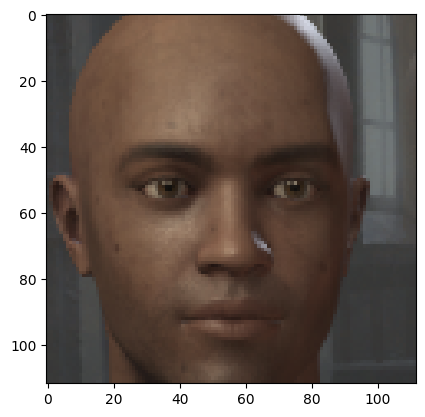

0.7254901960784312


In [65]:
def plot(i):
    plt.imshow(train_images[i])
    plt.show()
    print(skin_color[i])

plot(np.random.randint(0, skin_color.shape[0]))

### test correlation

In [76]:
def corr(a: np.ndarray, b: np.ndarray):
    a_centered = a - a.mean()
    b_centered = b - b.mean()
    return np.sum(a_centered * b_centered) / \
        np.sqrt((a_centered ** 2).sum() * (b_centered ** 2).sum())

In [87]:
pearsonr = np.array([corr(skin_color, Y_train[:, i]) for i in range(Y_train.shape[1])])

<BarContainer object of 512 artists>

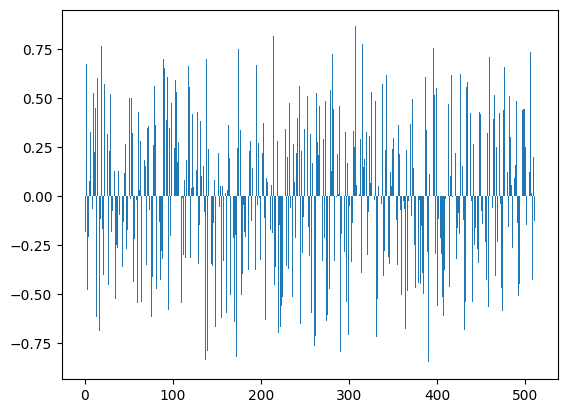

In [88]:
plt.bar(range(512), pearsonr)

# features from earlier leayers 

In [7]:
layer_names = ["_".join(l.split(".")) for l in layers_to_hook]
layer_names

['layer1_2_bn3', 'layer2_12_bn3', 'layer3_29_bn3', 'layer4_2_bn3']

In [8]:
DATASET_PATH = DATA_DIR / f"{GENESET}_geneset_embeddings"
IMAGES_PATH = DATASET_PATH / "alligned_images.npy"
images = np.load(IMAGES_PATH)
images.shape
images = np.moveaxis(images, -1, 1)

In [9]:
layers_to_hook

['layer1.2.bn3', 'layer2.12.bn3', 'layer3.29.bn3', 'layer4.2.bn3']

In [10]:
save_features_from_layers(model, layers_to_hook, images, DATASET_PATH)

235it [21:04,  5.38s/it]                         
